# Project: Alzheimer's Disease Classification from Brain MRI Images Using Deep Learning

Splitting of 2 classes per patient and source:
alzheimer
non_demented

---
## **1. Config**

In [ ]:
# ============================================================
# Imports
# ============================================================

import kagglehub
import pandas as pd
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib
import os
import shutil
import nibabel as nib
from PIL import Image
from pathlib import Path

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive

sns.set_style('darkgrid')

In [ ]:
# ============================================================
# Mount Drive
# ============================================================

drive.mount('/content/drive') #mount Google Drive to read images and csvs from there

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Reproducibility
# ============================================================

# removes most run-to-run variation
seed = 42
tf.keras.utils.set_random_seed(seed)

---
## **2. Spliting the images for training, validation and testing and creating the manifest csv and dataframe**

In [ ]:
# ============================================================
# Merge manifests
# ============================================================

project_path = '/content/drive/MyDrive/AlzheimersProject'

manifest_oasis_1 = pd.read_csv('/content/drive/MyDrive/AlzheimersProject/slices_2_classes/manifest.csv')
manifest_oasis_1['image_path'] = manifest_oasis_1['image_path'].str.replace('output/slices_2_classes', '/content/drive/MyDrive/AlzheimersProject/slices_2_classes', regex=False)
manifest_oasis_1['source'] = 'oasis_1'

manifest_oasis_2 = pd.read_csv('/content/drive/MyDrive/AlzheimersProject/oasis2/manifest_external.csv')
manifest_oasis_2['source'] = 'oasis_2'

manifest_df = pd.concat([manifest_oasis_1, manifest_oasis_2], ignore_index=True)

print(manifest_df.shape, manifest_oasis_1.shape, manifest_oasis_2.shape)
manifest_df.head()


(3180, 6) (1980, 6) (1200, 6)


,subject_id,label,cdr,image_path,label_id,source
0,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1
1,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1
2,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1
3,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1
4,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1


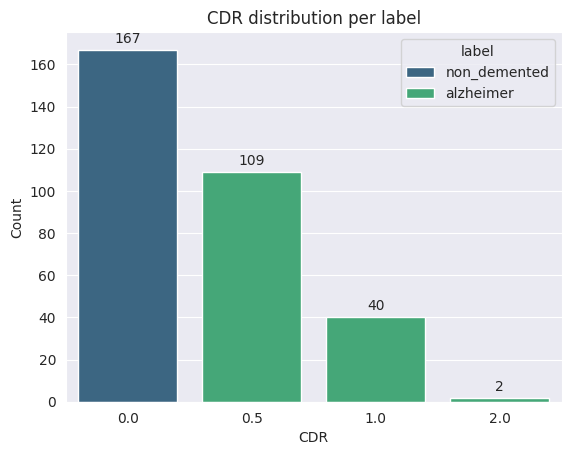

In [ ]:
# ============================================================
# CDR distribution
# ============================================================

cdr_df = manifest_df[["subject_id", "label", "cdr"]].drop_duplicates()

ax = sns.countplot(data=cdr_df, x="cdr", hue="label", palette="viridis")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.xlabel("CDR")
plt.ylabel("Count")
plt.title("CDR distribution per label")
plt.show()

In [ ]:
# ============================================================
# Splitting images/patients
# ============================================================

# Create one row per patient
patients = manifest_df[["subject_id", "label", "source"]].drop_duplicates()

# Stratify by label AND source: otherwise a split could end up with mostly one dataset, and we couldn't tell what we are measuring
patients["stratum"] = patients["label"] + "_" + patients["source"]

# Split patients into train (70%) and temporary (30%)
train_patients, valtest_patients = train_test_split(
    patients,
    test_size=0.30,
    stratify=patients["stratum"],
    random_state=seed,
)

# Split temporary set into validation (15%) and test (15%)
val_patients, test_patients = train_test_split(
    valtest_patients,
    test_size=0.50,
    stratify=valtest_patients["stratum"],
    random_state=seed,
)

# Verify that no patient appears in more than one split
assert set(train_patients.subject_id).isdisjoint(val_patients.subject_id)
assert set(train_patients.subject_id).isdisjoint(test_patients.subject_id)
assert set(val_patients.subject_id).isdisjoint(test_patients.subject_id)

# Create a mapping from subject_id to split name
split_map = {}
split_map.update({sid: "train" for sid in train_patients["subject_id"]})
split_map.update({sid: "val" for sid in val_patients["subject_id"]})
split_map.update({sid: "test" for sid in test_patients["subject_id"]})

# Add the split column to the full manifest
manifest_df["split"] = manifest_df["subject_id"].map(split_map)

# Save it back, now with the split column included
#manifest_df.to_csv("/content/drive/MyDrive/AlzheimersProject", index=False)

print("\nImages per split")
print(manifest_df["split"].value_counts())

print("\nPatients per split")
print(
    manifest_df[["subject_id", "split"]]
    .drop_duplicates()["split"]
    .value_counts()
)


Images per split
split
train    2220
val       480
test      480
Name: count, dtype: int64

Patients per split
split
train    222
val       48
test      48
Name: count, dtype: int64


In [ ]:
manifest_df.to_csv(f'{project_path}/oasis2/manifest_combined.csv', index=False)

In [ ]:
manifest_df.head()

,subject_id,label,cdr,image_path,label_id,source,split
0,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1,train
1,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1,train
2,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1,train
3,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1,train
4,OAS1_0308_MR1,alzheimer,2.0,/content/drive/MyDrive/AlzheimersProject/slice...,1,oasis_1,train


In [ ]:
pat = manifest_df[["subject_id", "split", "label", "source", "cdr"]].drop_duplicates()
print(pd.crosstab([pat.split, pat.source], pat.label))
print()
print(pd.crosstab(pat.split, pat.cdr))

label          alzheimer  non_demented
split source                          
test  oasis_1         15            15
      oasis_2          8            10
train oasis_1         70            68
      oasis_2         36            48
val   oasis_1         15            15
      oasis_2          7            11

cdr    0.0  0.5  1.0  2.0
split                    
test    25   18    5    0
train  116   75   30    1
val     26   16    5    1


In [ ]:
# ============================================================
# Splitting % distribution
# ============================================================

df_split = (pd.crosstab(manifest_df['label'], manifest_df['split'], normalize='index') * 100).round(2)
df_split.head()

split,test,train,val
label,,,
alzheimer,15.23,70.20,14.57
non_demented,14.97,69.46,15.57


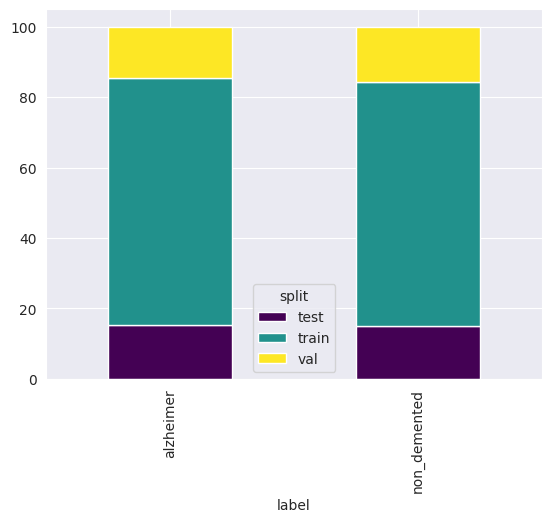

In [ ]:
# ============================================================
# Splitting % distribution
# ============================================================

df_split.plot(kind='bar', stacked=True, cmap='viridis')
plt.show()

In [ ]:
# ============================================================
# Image count per class/split
# ============================================================
df_classes = pd.crosstab(manifest_df['label'], manifest_df['split'], margins=True)
df_classes.head()

split,test,train,val,All
label,,,,
alzheimer,230,1060,220,1510
non_demented,250,1160,260,1670
All,480,2220,480,3180


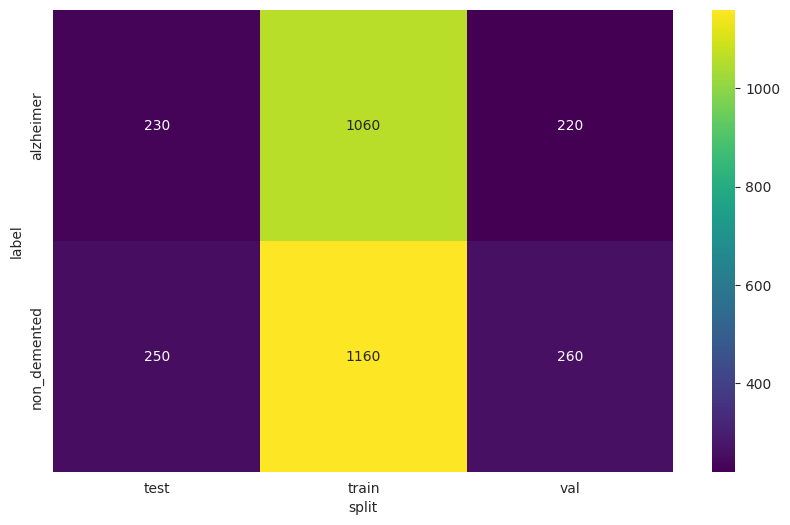

In [ ]:
# ============================================================
# Image count per class/split
# ============================================================

df_classes = pd.crosstab(manifest_df['label'], manifest_df['split'])
plt.figure(figsize=(10, 6))
sns.heatmap(df_classes, annot=True, fmt='d', cmap='viridis')
plt.show()

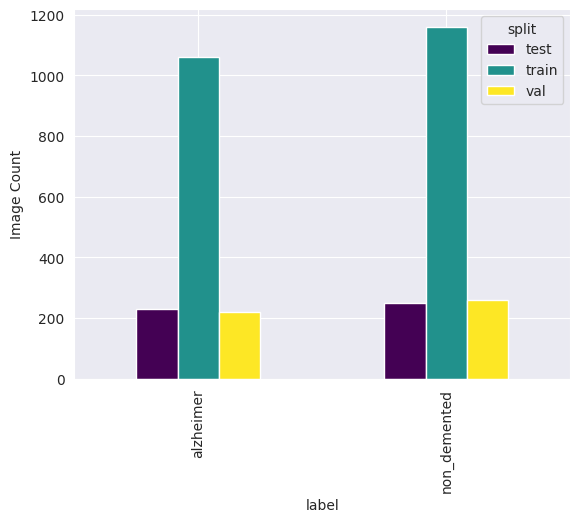

In [ ]:
# ============================================================
# Image count per class/split
# ============================================================

df_classes.plot(kind='bar', cmap = 'viridis')
plt.ylabel("Image Count")
plt.show()

In [ ]:
# ============================================================
# Patient count per class/split
# ============================================================

patient_count = manifest_df[["subject_id", "label","split"]].drop_duplicates()
patient_count = pd.crosstab(patient_count['label'], patient_count['split'], margins=True)
print(patient_count)

split         test  train  val  All
label                              
alzheimer       23    106   22  151
non_demented    25    116   26  167
All             48    222   48  318


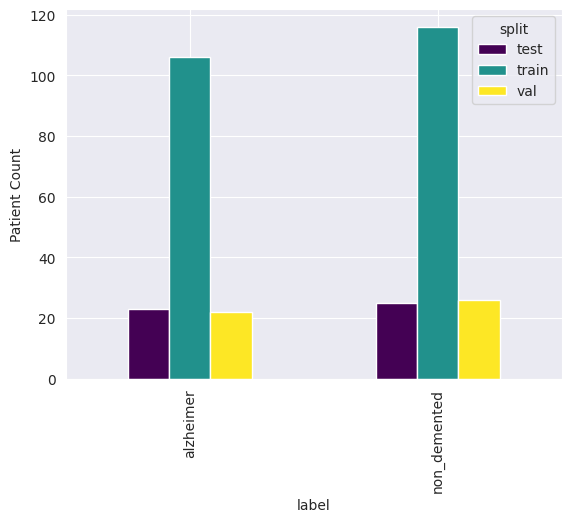

In [ ]:
# ============================================================
# Patient count per class/split
# ============================================================

patient_count = manifest_df[["subject_id", "label", "split"]].drop_duplicates()
patient_count = pd.crosstab(patient_count['label'], patient_count['split'])
patient_count.plot(kind='bar', cmap='viridis')
plt.ylabel("Patient Count")
plt.xticks(rotation=90)
plt.show()

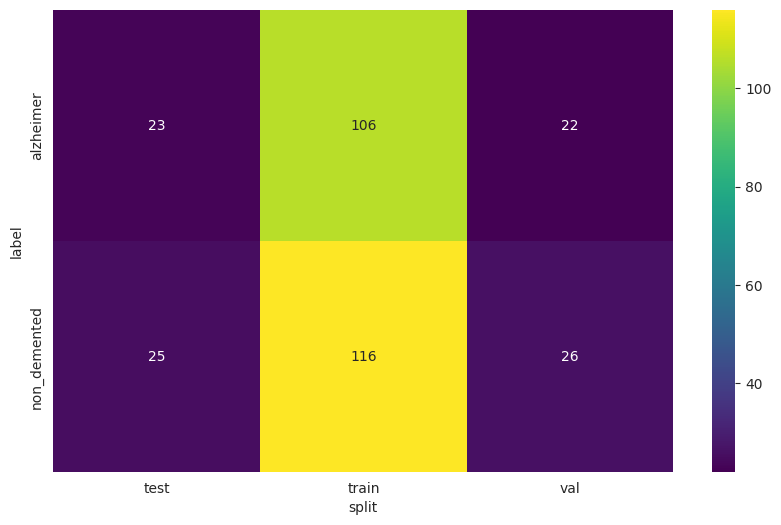

In [ ]:
# ============================================================
# Patient count per class/split
# ============================================================

plt.figure(figsize=(10, 6))
sns.heatmap(patient_count, annot=True, fmt='d', cmap='viridis')
plt.show()

In [ ]:
project_path = '/content/drive/MyDrive/AlzheimersProject'

total_df = pd.read_csv(f'{project_path}/oasis2/manifest_combined.csv')

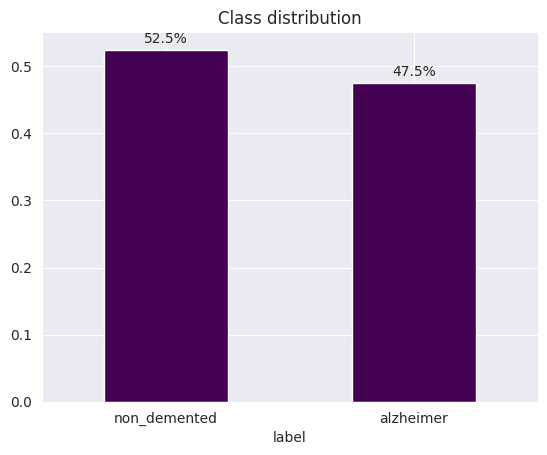

In [ ]:
ax = total_df['label'].value_counts(normalize=True).plot(
    kind='bar',
    title='Class distribution',
    cmap='viridis',
    rot=0
)

ax.bar_label(ax.containers[0], fmt='{:.1%}', padding=3)

plt.show()

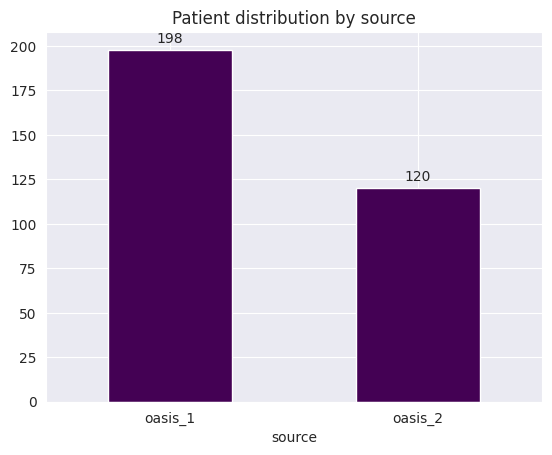

In [ ]:
patient_level_df = total_df[["subject_id", "label", "split", "source"]].drop_duplicates()

ax = patient_level_df['source'].value_counts().plot(
    kind='bar',
    title='Patient distribution by source',
    cmap='viridis',
    rot=0
)

ax.bar_label(ax.containers[0], padding=3)

plt.show()

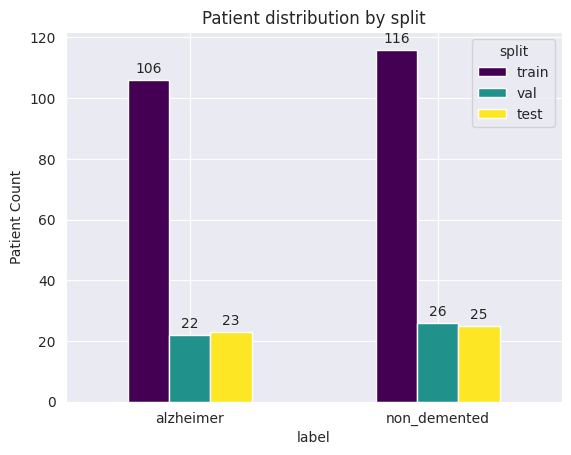

In [ ]:
patient_crosstab = pd.crosstab(patient_level_df['label'], patient_level_df['split'])
patient_crosstab = patient_crosstab[['train', 'val', 'test']]

ax = patient_crosstab.plot(kind='bar', cmap='viridis', rot=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.ylabel("Patient Count")
plt.title("Patient distribution by split")
plt.show()

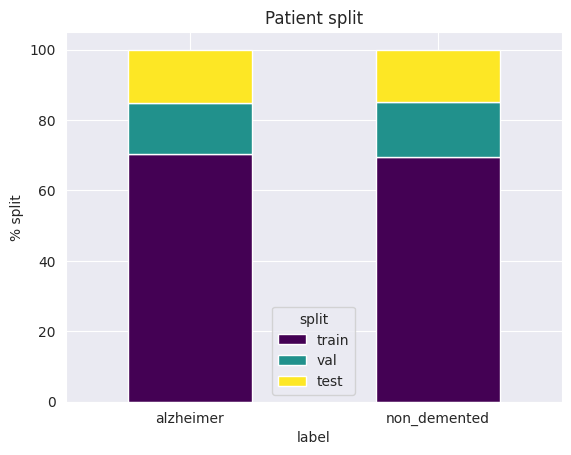

In [ ]:
patient_crosstab = pd.crosstab(patient_level_df['label'], patient_level_df['split'], normalize= 'index') * 100
patient_crosstab = patient_crosstab[['train', 'val', 'test']]

ax = patient_crosstab.plot(kind='bar', stacked=True, cmap='viridis', rot=0)

plt.ylabel("% split")
plt.title("Patient split")
plt.show()

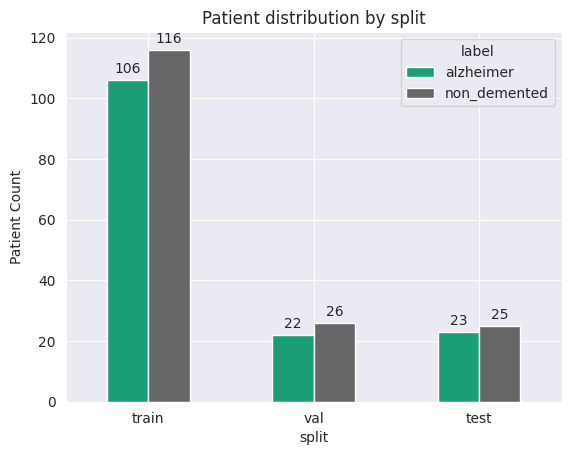

In [ ]:
patient_crosstab = pd.crosstab(patient_level_df['split'], patient_level_df['label'])

patient_crosstab = patient_crosstab.reindex(['train', 'val', 'test'])

ax = patient_crosstab.plot(kind='bar', cmap='Dark2', rot=0)

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.ylabel("Patient Count")
plt.title("Patient distribution by split")
plt.show()